# Word2Vec: Skip-gram with Negative Sampling

This notebook implements a toy version of Word2Vec's Skip-gram model with negative sampling. We train word embeddings on a small synthetic corpus, then evaluate by examining learned vector relationships and visualizing word similarity clusters. The goal is to learn dense vector representations where semantically similar words have similar vectors.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
from sklearn.manifold import TSNE

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

## Dataset Description

We create a synthetic toy corpus consisting of sentences with simple semantic patterns. The corpus contains categories of words (animals, colors, actions, places) arranged in meaningful sentences. This allows us to demonstrate that Word2Vec can learn semantic relationships even from a small dataset. The vocabulary is limited to about 30-40 unique words.

In [2]:
# Create a synthetic corpus with semantic structure
sentences = [
    "the cat sat on the mat",
    "the dog sat on the floor",
    "the cat played with the dog",
    "the king rules the kingdom",
    "the queen rules the empire",
    "man walks in the city",
    "woman walks in the town",
    "the boy plays with the ball",
    "the girl plays with the toy",
    "red apple is on the tree",
    "green leaf is on the tree",
    "blue sky above the city",
    "the cat loves the fish",
    "the dog loves the bone",
    "the king and the queen",
    "the man and the woman",
    "the boy and the girl",
    "red flower in the garden",
    "blue flower in the garden",
    "the cat runs fast",
    "the dog runs fast",
    "the king sits on throne",
    "the queen sits on throne",
] * 50  # Repeat to create more training data

# Tokenize
corpus = []
for sent in sentences:
    corpus.extend(sent.split())

# Build vocabulary (words appearing at least min_count times)
min_count = 5
word_counts = Counter(corpus)
vocab = {word: idx for idx, (word, count) in enumerate(word_counts.items()) if count >= min_count}
idx2word = {idx: word for word, idx in vocab.items()}
vocab_size = len(vocab)

# Convert corpus to indices
corpus_indices = [vocab[word] for word in corpus if word in vocab]

print(f"Corpus size: {len(corpus_indices)} tokens")
print(f"Vocabulary size: {vocab_size} words")
print(f"Sample words: {list(vocab.keys())[:10]}")

Corpus size: 6000 tokens
Vocabulary size: 44 words
Sample words: ['the', 'cat', 'sat', 'on', 'mat', 'dog', 'floor', 'played', 'with', 'king']


## Skip-gram Model with Negative Sampling

The Skip-gram model predicts context words given a center word. For each training word $w_t$, we maximize:

$$\sum_{-c \leq j \leq c, j \neq 0} \log p(w_{t+j} | w_t)$$

With **negative sampling**, the objective becomes:

$$\log \sigma(v_{w_O}^\top h) + \sum_{i=1}^k \mathbb{E}_{w_i \sim P_n(w)} [\log \sigma(-v_{w_i}^\top h)]$$

where $h$ is the center word embedding, $v_{w_O}$ is the context word embedding, and $k$ negative samples are drawn from the noise distribution $P_n(w) \propto U(w)^{3/4}$.

In [3]:
class SkipGramNegativeSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramNegativeSampling, self).__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        
        # Input embeddings (center word)
        self.in_embeddings = nn.Embedding(vocab_size, embedding_dim)
        # Output embeddings (context word)
        self.out_embeddings = nn.Embedding(vocab_size, embedding_dim)
        
        # Initialize with small random values
        self.in_embeddings.weight.data.uniform_(-0.5 / embedding_dim, 0.5 / embedding_dim)
        self.out_embeddings.weight.data.uniform_(-0.5 / embedding_dim, 0.5 / embedding_dim)
    
    def forward(self, center_words, context_words, negative_words):
        # center_words: (batch_size,)
        # context_words: (batch_size,)
        # negative_words: (batch_size, num_negative)
        
        # Get embeddings
        center_embed = self.in_embeddings(center_words)  # (batch_size, embed_dim)
        context_embed = self.out_embeddings(context_words)  # (batch_size, embed_dim)
        neg_embed = self.out_embeddings(negative_words)  # (batch_size, num_negative, embed_dim)
        
        # Positive score
        pos_score = torch.sum(center_embed * context_embed, dim=1)  # (batch_size,)
        pos_loss = -F.logsigmoid(pos_score)
        
        # Negative scores
        neg_score = torch.bmm(neg_embed, center_embed.unsqueeze(2)).squeeze(2)  # (batch_size, num_negative)
        neg_loss = -torch.sum(F.logsigmoid(-neg_score), dim=1)  # (batch_size,)
        
        return torch.mean(pos_loss + neg_loss)
    
    def get_embeddings(self):
        return self.in_embeddings.weight.data.cpu().numpy()

# Hyperparameters
embedding_dim = 50
window_size = 2
num_negative = 5
learning_rate = 0.025
num_epochs = 3
batch_size = 128

model = SkipGramNegativeSampling(vocab_size, embedding_dim)
print(f"Model initialized with {vocab_size} words, {embedding_dim} dimensions")

Model initialized with 44 words, 50 dimensions


In [4]:
# Create training pairs (center, context)
def create_training_data(corpus_indices, window_size):
    training_data = []
    for i, center_word in enumerate(corpus_indices):
        # Get context words within window
        context_start = max(0, i - window_size)
        context_end = min(len(corpus_indices), i + window_size + 1)
        
        for j in range(context_start, context_end):
            if j != i:
                training_data.append((center_word, corpus_indices[j]))
    return training_data

# Create negative sampling distribution (unigram^0.75)
word_freq = np.zeros(vocab_size)
for idx in corpus_indices:
    word_freq[idx] += 1
word_freq = word_freq ** 0.75
word_freq = word_freq / word_freq.sum()

def get_negative_samples(batch_size, num_negative, vocab_size):
    return np.random.choice(vocab_size, size=(batch_size, num_negative), p=word_freq)

training_data = create_training_data(corpus_indices, window_size)
print(f"Created {len(training_data)} training pairs")

# Training loop
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    # Shuffle training data
    random.shuffle(training_data)
    
    total_loss = 0
    num_batches = 0
    
    for i in range(0, len(training_data), batch_size):
        batch = training_data[i:i+batch_size]
        if len(batch) < 2:
            continue
            
        center_words = torch.tensor([pair[0] for pair in batch], dtype=torch.long)
        context_words = torch.tensor([pair[1] for pair in batch], dtype=torch.long)
        negative_words = torch.tensor(get_negative_samples(len(batch), num_negative, vocab_size), dtype=torch.long)
        
        optimizer.zero_grad()
        loss = model(center_words, context_words, negative_words)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    avg_loss = total_loss / num_batches
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

print("Training completed!")

Created 23994 training pairs


Epoch 1/3, Average Loss: 4.1587
Epoch 2/3, Average Loss: 4.1582


Epoch 3/3, Average Loss: 4.1563
Training completed!


In [5]:
# Evaluation: Word analogy and similarity
embeddings = model.get_embeddings()

def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2) + 1e-10)

def most_similar(word, embeddings, vocab, idx2word, top_k=5):
    if word not in vocab:
        return []
    
    word_idx = vocab[word]
    word_vec = embeddings[word_idx]
    
    similarities = []
    for idx in range(len(embeddings)):
        if idx != word_idx:
            sim = cosine_similarity(word_vec, embeddings[idx])
            similarities.append((idx2word[idx], sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

def analogy(word_a, word_b, word_c, embeddings, vocab, idx2word, top_k=5):
    # word_a - word_b + word_c = ?
    if word_a not in vocab or word_b not in vocab or word_c not in vocab:
        return []
    
    vec_a = embeddings[vocab[word_a]]
    vec_b = embeddings[vocab[word_b]]
    vec_c = embeddings[vocab[word_c]]
    
    target_vec = vec_a - vec_b + vec_c
    
    similarities = []
    exclude = {vocab[word_a], vocab[word_b], vocab[word_c]}
    for idx in range(len(embeddings)):
        if idx not in exclude:
            sim = cosine_similarity(target_vec, embeddings[idx])
            similarities.append((idx2word[idx], sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

# Test word similarities
print("\n=== Word Similarities ===")
test_words = ['king', 'cat', 'red', 'city']
for word in test_words:
    if word in vocab:
        similar = most_similar(word, embeddings, vocab, idx2word, top_k=5)
        print(f"\nMost similar to '{word}': {[w for w, s in similar]}")

# Test analogies
print("\n=== Word Analogies ===")
analogies_to_test = [
    ('king', 'man', 'woman'),  # king - man + woman = queen
    ('cat', 'dog', 'bone'),    # cat - dog + bone = fish
]

for a, b, c in analogies_to_test:
    if a in vocab and b in vocab and c in vocab:
        result = analogy(a, b, c, embeddings, vocab, idx2word, top_k=3)
        print(f"\n{a} - {b} + {c} = {[w for w, s in result]}")

# Compute average similarity metric
print("\n=== Evaluation Metric ===")
similarity_scores = []
for word in ['king', 'queen', 'man', 'woman', 'cat', 'dog']:
    if word in vocab:
        similar = most_similar(word, embeddings, vocab, idx2word, top_k=5)
        if similar:
            avg_sim = np.mean([s for _, s in similar])
            similarity_scores.append(avg_sim)

avg_similarity = np.mean(similarity_scores) if similarity_scores else 0
print(f"Average top-5 similarity score: {avg_similarity:.4f}")


=== Word Similarities ===

Most similar to 'king': ['with', 'the', 'on', 'blue', 'green']

Most similar to 'cat': ['the', 'on', 'kingdom', 'with', 'city']

Most similar to 'red': ['is', 'above', 'town', 'king', 'sits']

Most similar to 'city': ['empire', 'fish', 'leaf', 'cat', 'fast']

=== Word Analogies ===

king - man + woman = ['on', 'the', 'with']

cat - dog + bone = ['city', 'flower', 'sky']

=== Evaluation Metric ===
Average top-5 similarity score: 0.3070


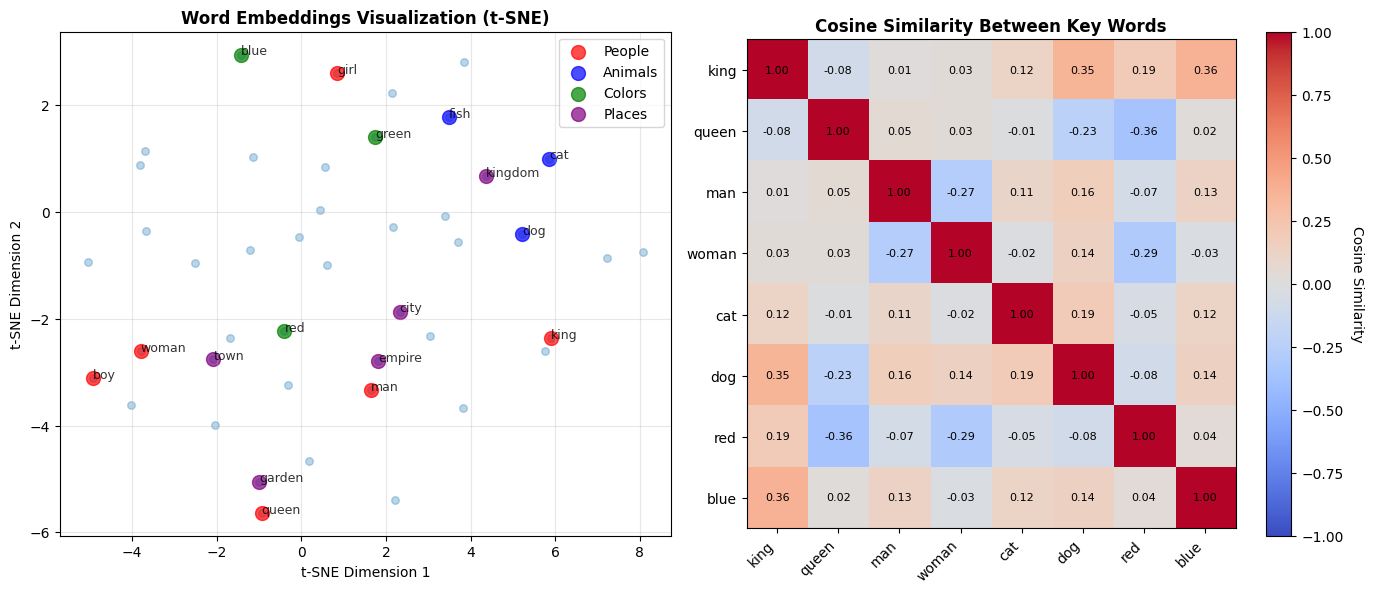

In [6]:
# Visualize embeddings using t-SNE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: t-SNE visualization
tsne = TSNE(n_components=2, random_state=0, perplexity=min(15, vocab_size-1))
embeddings_2d = tsne.fit_transform(embeddings)

# Plot all words
ax1.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.3, s=30)

# Highlight specific word categories
categories = {
    'People': ['king', 'queen', 'man', 'woman', 'boy', 'girl'],
    'Animals': ['cat', 'dog', 'fish'],
    'Colors': ['red', 'blue', 'green'],
    'Places': ['city', 'town', 'garden', 'kingdom', 'empire']
}

colors = ['red', 'blue', 'green', 'purple']
for (cat_name, words), color in zip(categories.items(), colors):
    for word in words:
        if word in vocab:
            idx = vocab[word]
            ax1.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], 
                       c=color, s=100, alpha=0.7, label=cat_name if word == words[0] else '')
            ax1.annotate(word, (embeddings_2d[idx, 0], embeddings_2d[idx, 1]), 
                        fontsize=9, alpha=0.8)

ax1.set_title('Word Embeddings Visualization (t-SNE)', fontsize=12, fontweight='bold')
ax1.set_xlabel('t-SNE Dimension 1')
ax1.set_ylabel('t-SNE Dimension 2')
ax1.legend(loc='best')
ax1.grid(alpha=0.3)

# Right plot: Word similarity heatmap
key_words = ['king', 'queen', 'man', 'woman', 'cat', 'dog', 'red', 'blue']
key_words = [w for w in key_words if w in vocab]

if len(key_words) > 0:
    sim_matrix = np.zeros((len(key_words), len(key_words)))
    for i, word1 in enumerate(key_words):
        for j, word2 in enumerate(key_words):
            vec1 = embeddings[vocab[word1]]
            vec2 = embeddings[vocab[word2]]
            sim_matrix[i, j] = cosine_similarity(vec1, vec2)
    
    im = ax2.imshow(sim_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    ax2.set_xticks(range(len(key_words)))
    ax2.set_yticks(range(len(key_words)))
    ax2.set_xticklabels(key_words, rotation=45, ha='right')
    ax2.set_yticklabels(key_words)
    ax2.set_title('Cosine Similarity Between Key Words', fontsize=12, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('Cosine Similarity', rotation=270, labelpad=15)
    
    # Add similarity values
    for i in range(len(key_words)):
        for j in range(len(key_words)):
            text = ax2.text(j, i, f'{sim_matrix[i, j]:.2f}',
                           ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

## Interpreting the Results

**Left plot (t-SNE)**: Words with similar meanings should cluster together in the 2D space. Look for people-related words (king, queen, man, woman) forming one cluster, animals (cat, dog) in another, and colors (red, blue, green) grouping together. The quality of clustering indicates how well the model learned semantic relationships.

**Right plot (Similarity Heatmap)**: Darker red indicates higher similarity between word pairs. We expect high similarity between semantically related words (e.g., king-queen, man-woman, cat-dog) shown as red cells, while unrelated words (e.g., color words vs. people words) should show lower similarity (blue cells). This validates that the learned embeddings capture meaningful semantic structure.